Campaign dataset: (24, 10)
Audience dataset: (6, 6)


,Campaign_ID,Date,Channel,Content_Type,Audience,Impressions,Clicks,Conversions,Spend_INR,Revenue_INR
0,C001,2026-07-01,Instagram,Reel,Gen Z,12500,875,42,3200,12600
1,C002,2026-07-02,Instagram,Carousel,Young Professionals,9800,588,31,2600,9300
2,C003,2026-07-03,Google Ads,Search Ad,Young Professionals,15400,1078,56,5100,16800
3,C004,2026-07-04,Email,Newsletter,Existing Customers,6200,806,48,900,14400
4,C005,2026-07-05,Instagram,Story,Gen Z,11300,678,29,2100,8700



========== DATA QUALITY ==========

Missing values:


Campaign_ID     0
Date            0
Channel         0
Content_Type    0
Audience        0
Impressions     0
Clicks          0
Conversions     0
Spend_INR       0
Revenue_INR     0
dtype: int64


Duplicate rows: 0

========== CAMPAIGN KPIs ==========


...

,Channel,Impressions,Clicks,Conversions,Spend,Revenue,CTR_%,Conversion_Rate_%,ROAS
0,Email,42200,5794,355,6300,106500,13.73,6.13,16.90
1,Google Ads,123000,7922,378,36700,113400,6.44,4.77,3.09
2,Instagram,136800,9590,453,31600,135900,7.01,4.72,4.30



========== AUDIENCE PERFORMANCE ==========


,Audience,Impressions,Clicks,Conversions,Spend,Revenue,CTR_%,Conversion_Rate_%,ROAS
0,Existing Customers,35100,5013,316,5350,94800,14.28,6.30,17.72
2,Skincare Seekers,96900,7464,369,27600,110700,7.70,4.94,4.01
3,Young Professionals,90900,6054,293,24050,87900,6.66,4.84,3.65
1,Gen Z,79100,4775,208,17600,62400,6.04,4.36,3.55



========== CONTENT PERFORMANCE ==========


,Content_Type,Impressions,Clicks,Conversions,Spend,Revenue,CTR_%,Conversion_Rate_%,ROAS
3,Product Email,22000,3310,213,3550,63900,15.05,6.44,18.00
2,Newsletter,20200,2484,142,2750,42600,12.30,5.72,15.49
4,Reel,70900,5411,259,17100,77700,7.63,4.79,4.54
6,Story,23400,1404,63,4300,18900,6.00,4.49,4.40
0,Carousel,42500,2775,131,10200,39300,6.53,4.72,3.85
5,Search Ad,87600,6506,329,28500,98700,7.43,5.06,3.46
1,Display Ad,35400,1416,49,8200,14700,4.00,3.46,1.79


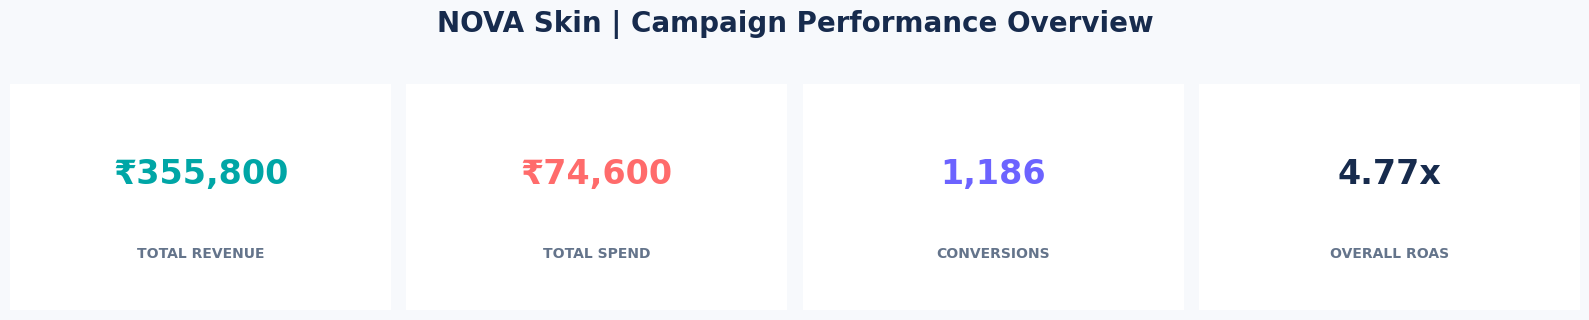

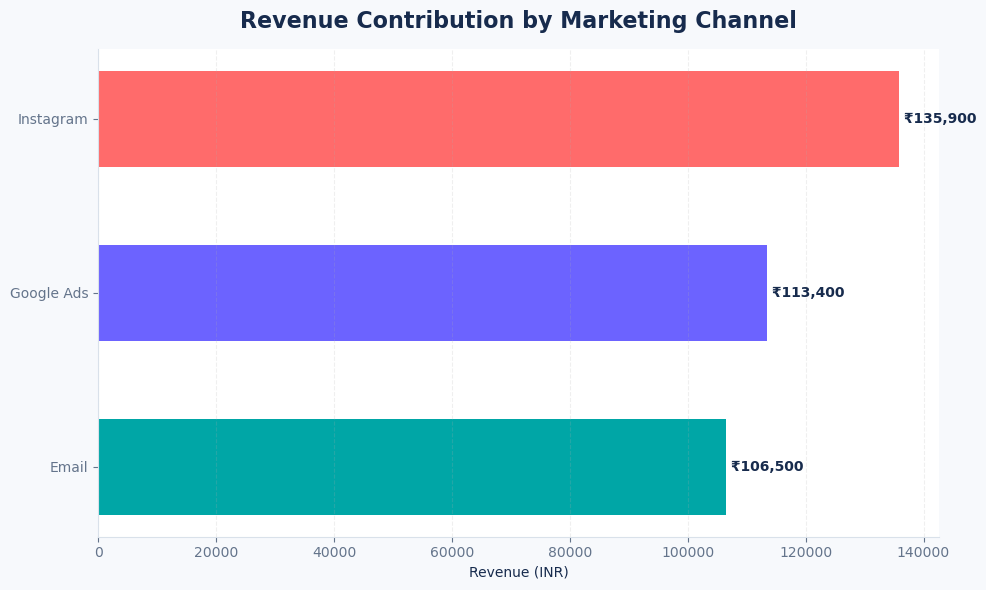

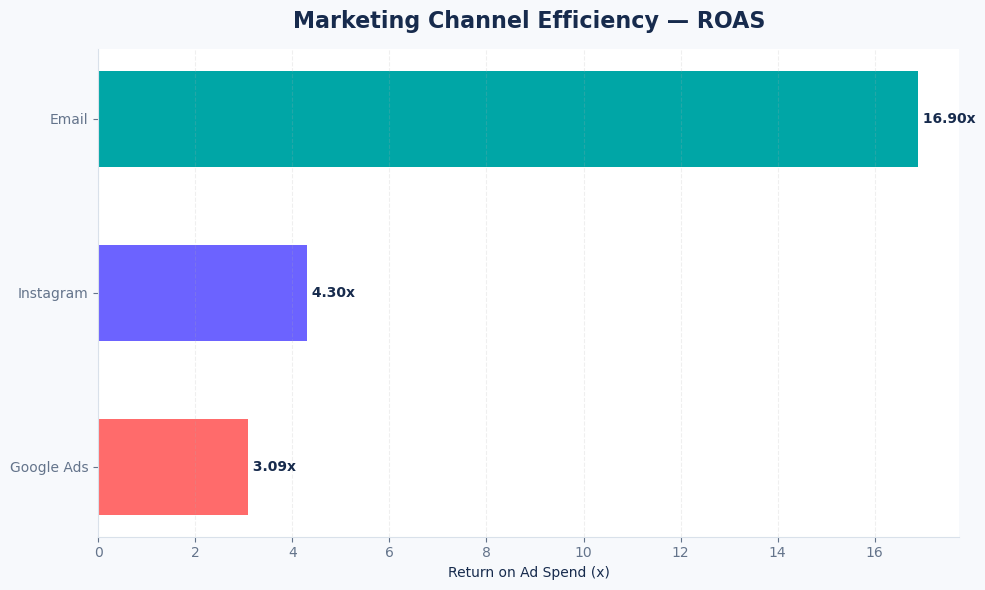

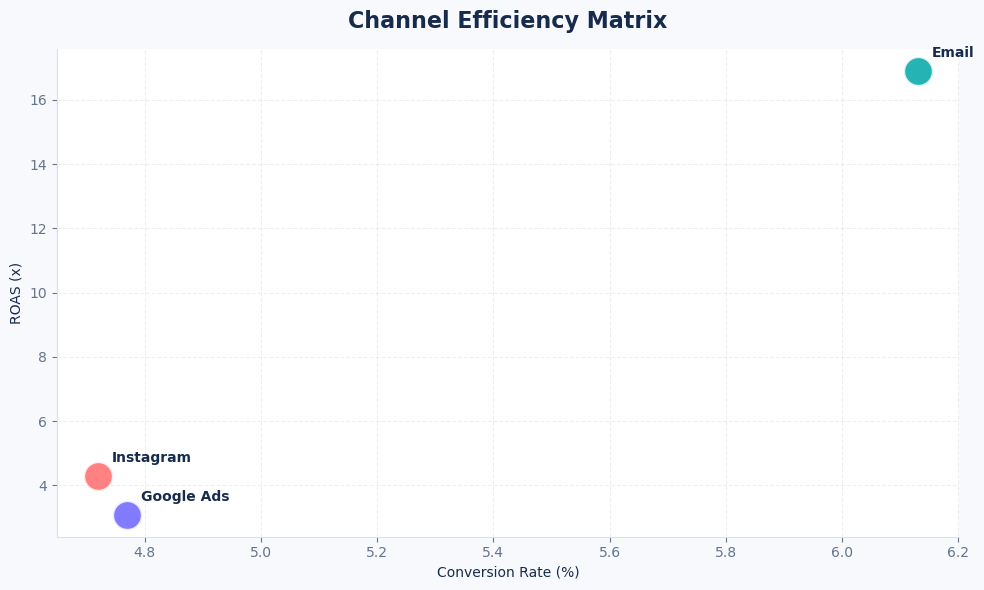

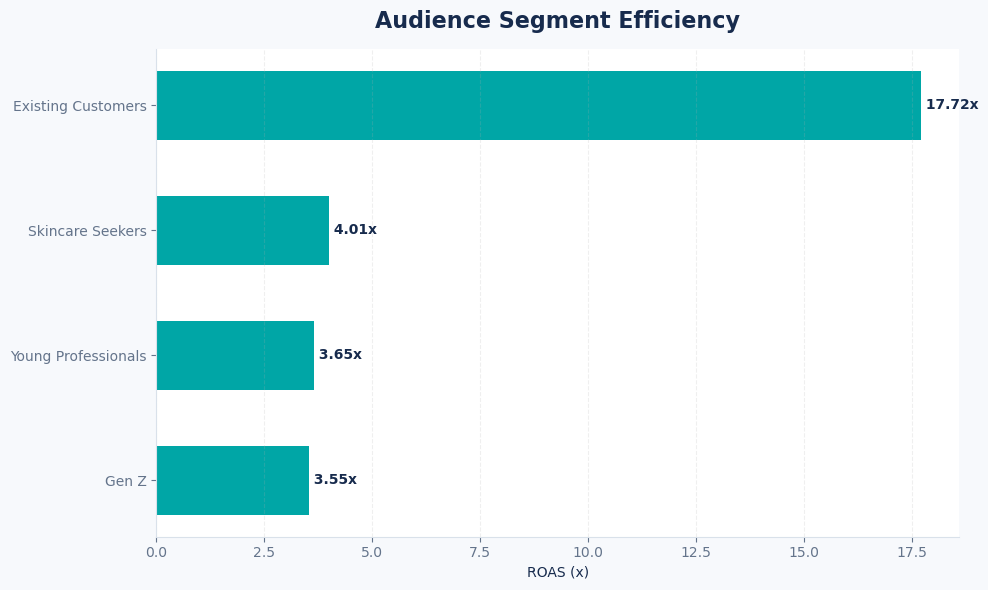

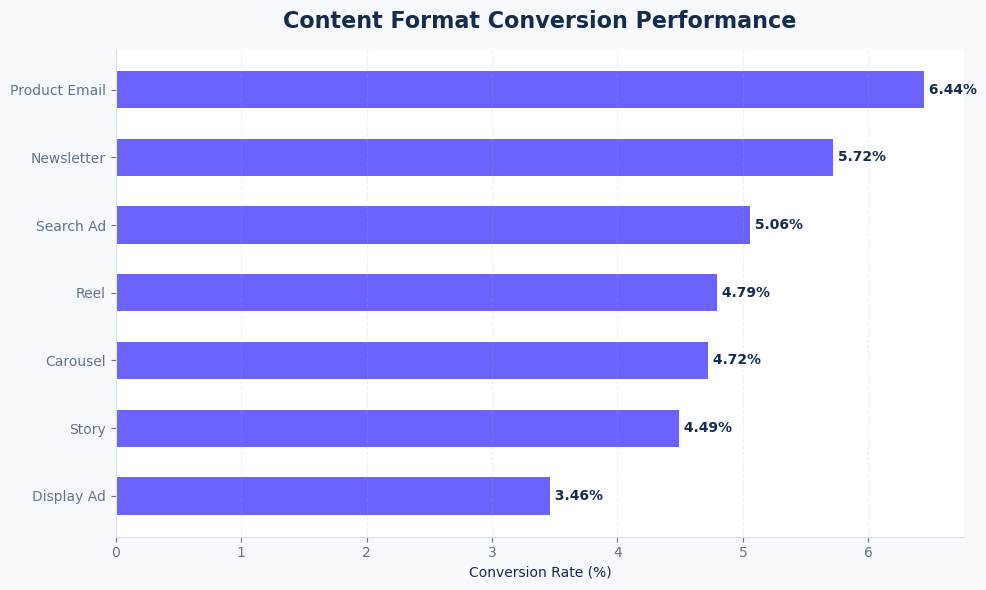

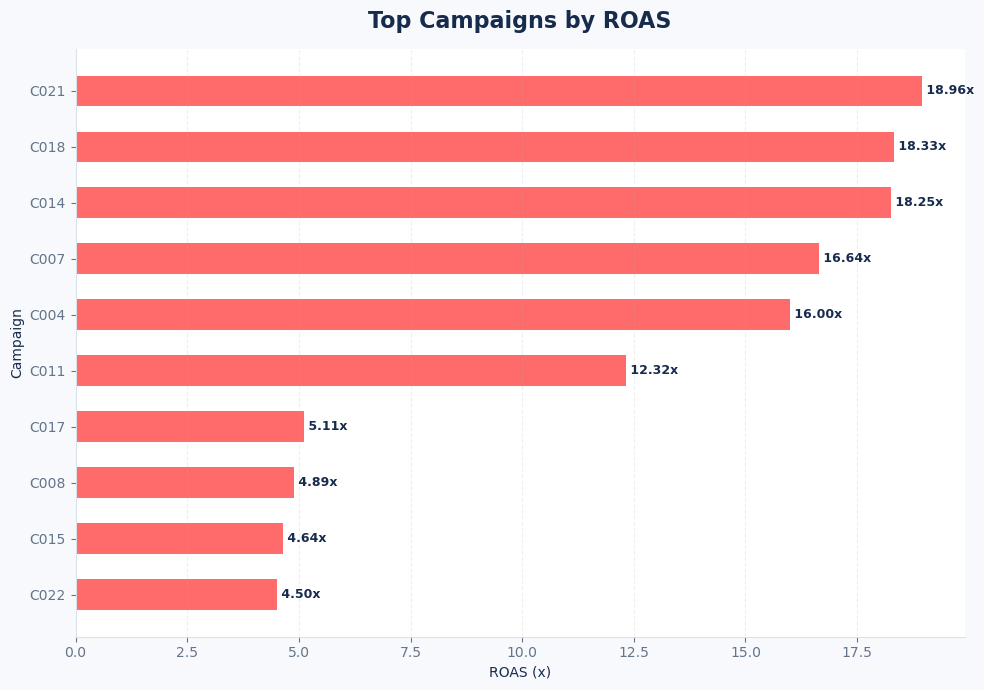

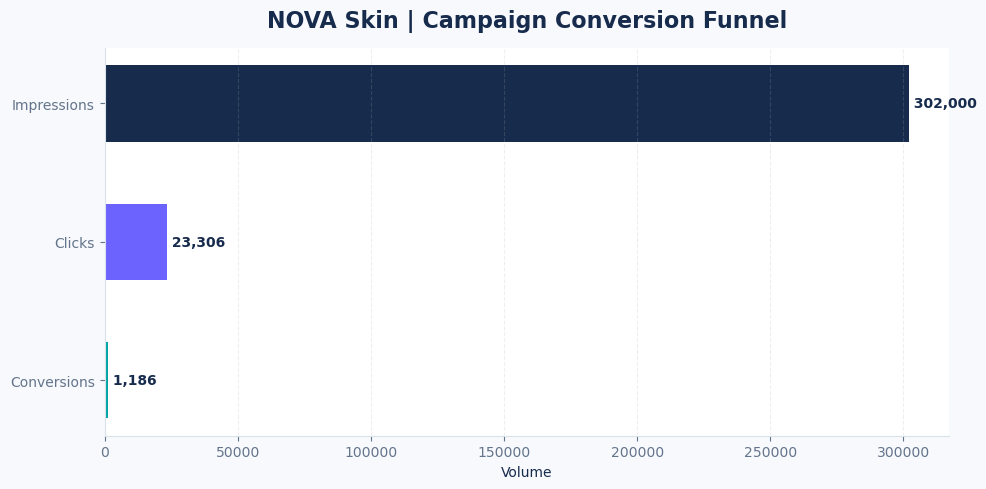



NOVA SKIN — KEY MARKETING INSIGHTS

1. Highest ROAS channel: Email (16.90x)

2. Highest ROAS audience: Existing Customers (17.72x)

3. Highest ROAS content format: Product Email (18.00x)

4. The campaign can be optimized by comparing channel efficiency with audience response.

5. Future campaigns should validate these patterns through controlled A/B testing.



In [3]:
# ============================================================
# NOVA SKIN — AI MARKETING CAMPAIGN ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# BRAND STYLE
# ============================================================

NAVY = "#172B4D"
TEAL = "#00A6A6"
CORAL = "#FF6B6B"
PURPLE = "#6C63FF"
BLUE = "#3B82F6"
LIGHT_BG = "#F7F9FC"
GREY = "#64748B"

plt.rcParams.update({
    "figure.facecolor": LIGHT_BG,
    "axes.facecolor": "white",
    "axes.edgecolor": "#D9E1EA",
    "axes.labelcolor": NAVY,
    "xtick.color": GREY,
    "ytick.color": GREY,
    "font.size": 10,
    "axes.titleweight": "bold",
    "axes.titlesize": 16
})


# ============================================================
# 1. LOAD DATA
# ============================================================

campaign = pd.read_csv("../data/campaign_performance.csv")
audience = pd.read_csv("../data/audience_segments.csv")

print("Campaign dataset:", campaign.shape)
print("Audience dataset:", audience.shape)

display(campaign.head())


# ============================================================
# 2. DATA QUALITY CHECK
# ============================================================

print("\n========== DATA QUALITY ==========")

print("\nMissing values:")
display(campaign.isnull().sum())

print("\nDuplicate rows:", campaign.duplicated().sum())


# ============================================================
# 3. CALCULATE MARKETING KPIs
# ============================================================

campaign["CTR_%"] = (
    campaign["Clicks"] /
    campaign["Impressions"] * 100
).round(2)

campaign["Conversion_Rate_%"] = (
    campaign["Conversions"] /
    campaign["Clicks"] * 100
).round(2)

campaign["ROAS"] = (
    campaign["Revenue_INR"] /
    campaign["Spend_INR"]
).round(2)

print("\n========== CAMPAIGN KPIs ==========")

display(
    campaign[
        [
            "Campaign_ID",
            "Channel",
            "Audience",
            "CTR_%",
            "Conversion_Rate_%",
            "ROAS"
        ]
    ].head(10)
)


# ============================================================
# 4. OVERALL PERFORMANCE
# ============================================================

total_impressions = campaign["Impressions"].sum()
total_clicks = campaign["Clicks"].sum()
total_conversions = campaign["Conversions"].sum()
total_spend = campaign["Spend_INR"].sum()
total_revenue = campaign["Revenue_INR"].sum()

overall_ctr = total_clicks / total_impressions * 100
overall_conversion_rate = total_conversions / total_clicks * 100
overall_roas = total_revenue / total_spend

print("\n========== OVERALL CAMPAIGN PERFORMANCE ==========")

print(f"Total Impressions : {total_impressions:,}")
print(f"Total Clicks      : {total_clicks:,}")
print(f"Total Conversions : {total_conversions:,}")
print(f"Total Spend       : ₹{total_spend:,.0f}")
print(f"Total Revenue     : ₹{total_revenue:,.0f}")
print(f"Overall CTR       : {overall_ctr:.2f}%")
print(f"Conversion Rate   : {overall_conversion_rate:.2f}%")
print(f"Overall ROAS      : {overall_roas:.2f}x")


# ============================================================
# 5. CHANNEL PERFORMANCE
# ============================================================

channel_performance = campaign.groupby("Channel").agg(
    Impressions=("Impressions", "sum"),
    Clicks=("Clicks", "sum"),
    Conversions=("Conversions", "sum"),
    Spend=("Spend_INR", "sum"),
    Revenue=("Revenue_INR", "sum")
).reset_index()

channel_performance["CTR_%"] = (
    channel_performance["Clicks"] /
    channel_performance["Impressions"] * 100
).round(2)

channel_performance["Conversion_Rate_%"] = (
    channel_performance["Conversions"] /
    channel_performance["Clicks"] * 100
).round(2)

channel_performance["ROAS"] = (
    channel_performance["Revenue"] /
    channel_performance["Spend"]
).round(2)

print("\n========== CHANNEL PERFORMANCE ==========")

display(channel_performance)


# ============================================================
# 6. AUDIENCE PERFORMANCE
# ============================================================

audience_performance = campaign.groupby("Audience").agg(
    Impressions=("Impressions", "sum"),
    Clicks=("Clicks", "sum"),
    Conversions=("Conversions", "sum"),
    Spend=("Spend_INR", "sum"),
    Revenue=("Revenue_INR", "sum")
).reset_index()

audience_performance["CTR_%"] = (
    audience_performance["Clicks"] /
    audience_performance["Impressions"] * 100
).round(2)

audience_performance["Conversion_Rate_%"] = (
    audience_performance["Conversions"] /
    audience_performance["Clicks"] * 100
).round(2)

audience_performance["ROAS"] = (
    audience_performance["Revenue"] /
    audience_performance["Spend"]
).round(2)

print("\n========== AUDIENCE PERFORMANCE ==========")

display(
    audience_performance.sort_values(
        "ROAS",
        ascending=False
    )
)


# ============================================================
# 7. CONTENT FORMAT PERFORMANCE
# ============================================================

content_performance = campaign.groupby("Content_Type").agg(
    Impressions=("Impressions", "sum"),
    Clicks=("Clicks", "sum"),
    Conversions=("Conversions", "sum"),
    Spend=("Spend_INR", "sum"),
    Revenue=("Revenue_INR", "sum")
).reset_index()

content_performance["CTR_%"] = (
    content_performance["Clicks"] /
    content_performance["Impressions"] * 100
).round(2)

content_performance["Conversion_Rate_%"] = (
    content_performance["Conversions"] /
    content_performance["Clicks"] * 100
).round(2)

content_performance["ROAS"] = (
    content_performance["Revenue"] /
    content_performance["Spend"]
).round(2)

print("\n========== CONTENT PERFORMANCE ==========")

display(
    content_performance.sort_values(
        "ROAS",
        ascending=False
    )
)


# ============================================================
# 8. KPI OVERVIEW
# ============================================================

fig, axes = plt.subplots(
    1,
    4,
    figsize=(16, 3)
)

fig.patch.set_facecolor(LIGHT_BG)

kpis = [
    ("TOTAL REVENUE", f"₹{total_revenue:,.0f}", TEAL),
    ("TOTAL SPEND", f"₹{total_spend:,.0f}", CORAL),
    ("CONVERSIONS", f"{total_conversions:,}", PURPLE),
    ("OVERALL ROAS", f"{overall_roas:.2f}x", NAVY)
]

for ax, (title, value, color) in zip(axes, kpis):

    ax.set_facecolor("white")

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.text(
        0.5,
        0.60,
        value,
        ha="center",
        va="center",
        fontsize=24,
        fontweight="bold",
        color=color
    )

    ax.text(
        0.5,
        0.25,
        title,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=GREY
    )

    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(
    "NOVA Skin | Campaign Performance Overview",
    fontsize=20,
    fontweight="bold",
    color=NAVY,
    y=1.05
)

plt.tight_layout()
plt.show()


# ============================================================
# 9. CHANNEL REVENUE
# ============================================================

channel_sorted = channel_performance.sort_values(
    "Revenue",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    channel_sorted["Channel"],
    channel_sorted["Revenue"],
    color=[TEAL, PURPLE, CORAL],
    height=0.55
)

ax.set_title(
    "Revenue Contribution by Marketing Channel",
    color=NAVY,
    pad=15
)

ax.set_xlabel("Revenue (INR)")
ax.set_ylabel("")

for bar, value in zip(
    bars,
    channel_sorted["Revenue"]
):

    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" ₹{value:,.0f}",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=NAVY
    )

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.2
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# ============================================================
# 10. CHANNEL ROAS
# ============================================================

channel_roas = channel_performance.sort_values(
    "ROAS",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    channel_roas["Channel"],
    channel_roas["ROAS"],
    color=[CORAL, PURPLE, TEAL],
    height=0.55
)

ax.set_title(
    "Marketing Channel Efficiency — ROAS",
    color=NAVY,
    pad=15
)

ax.set_xlabel("Return on Ad Spend (x)")
ax.set_ylabel("")

for bar, value in zip(
    bars,
    channel_roas["ROAS"]
):

    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {value:.2f}x",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=NAVY
    )

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.2
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# ============================================================
# 11. ROAS VS CONVERSION RATE
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

channel_colors = {
    "Instagram": CORAL,
    "Google Ads": PURPLE,
    "Email": TEAL
}

for _, row in channel_performance.iterrows():

    ax.scatter(
        row["Conversion_Rate_%"],
        row["ROAS"],
        s=450,
        color=channel_colors.get(
            row["Channel"],
            BLUE
        ),
        alpha=0.85,
        edgecolor="white",
        linewidth=2
    )

    ax.annotate(
        row["Channel"],
        (
            row["Conversion_Rate_%"],
            row["ROAS"]
        ),
        xytext=(10, 10),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
        color=NAVY
    )

ax.set_title(
    "Channel Efficiency Matrix",
    color=NAVY,
    pad=15
)

ax.set_xlabel("Conversion Rate (%)")
ax.set_ylabel("ROAS (x)")

ax.grid(
    linestyle="--",
    alpha=0.2
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# ============================================================
# 12. AUDIENCE PERFORMANCE
# ============================================================

audience_sorted = audience_performance.sort_values(
    "ROAS",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    audience_sorted["Audience"],
    audience_sorted["ROAS"],
    color=TEAL,
    height=0.55
)

ax.set_title(
    "Audience Segment Efficiency",
    color=NAVY,
    pad=15
)

ax.set_xlabel("ROAS (x)")
ax.set_ylabel("")

for bar, value in zip(
    bars,
    audience_sorted["ROAS"]
):

    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {value:.2f}x",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=NAVY
    )

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.2
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# ============================================================
# 13. CONTENT FORMAT PERFORMANCE
# ============================================================

content_sorted = content_performance.sort_values(
    "Conversion_Rate_%",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    content_sorted["Content_Type"],
    content_sorted["Conversion_Rate_%"],
    color=PURPLE,
    height=0.55
)

ax.set_title(
    "Content Format Conversion Performance",
    color=NAVY,
    pad=15
)

ax.set_xlabel("Conversion Rate (%)")
ax.set_ylabel("")

for bar, value in zip(
    bars,
    content_sorted["Conversion_Rate_%"]
):

    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {value:.2f}%",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=NAVY
    )

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.2
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# ============================================================
# 14. TOP CAMPAIGNS
# ============================================================

top_campaigns = campaign.sort_values(
    "ROAS",
    ascending=False
).head(10)

top_campaigns = top_campaigns.sort_values(
    "ROAS",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    top_campaigns["Campaign_ID"],
    top_campaigns["ROAS"],
    color=CORAL,
    height=0.55
)

ax.set_title(
    "Top Campaigns by ROAS",
    color=NAVY,
    pad=15
)

ax.set_xlabel("ROAS (x)")
ax.set_ylabel("Campaign")

for bar, value in zip(
    bars,
    top_campaigns["ROAS"]
):

    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {value:.2f}x",
        va="center",
        fontsize=9,
        fontweight="bold",
        color=NAVY
    )

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.2
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# ============================================================
# 15. CONVERSION FUNNEL
# ============================================================

funnel_labels = [
    "Impressions",
    "Clicks",
    "Conversions"
]

funnel_values = [
    total_impressions,
    total_clicks,
    total_conversions
]

funnel_colors = [
    NAVY,
    PURPLE,
    TEAL
]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    funnel_labels,
    funnel_values,
    color=funnel_colors,
    height=0.55
)

ax.set_title(
    "NOVA Skin | Campaign Conversion Funnel",
    color=NAVY,
    pad=15
)

ax.set_xlabel("Volume")

ax.invert_yaxis()

for bar, value in zip(
    bars,
    funnel_values
):

    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {value:,}",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=NAVY
    )

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.2
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# ============================================================
# 16. TOP MARKETING INSIGHTS
# ============================================================

best_channel = channel_performance.loc[
    channel_performance["ROAS"].idxmax()
]

best_audience = audience_performance.loc[
    audience_performance["ROAS"].idxmax()
]

best_content = content_performance.loc[
    content_performance["ROAS"].idxmax()
]

print("\n")
print("=" * 60)
print("NOVA SKIN — KEY MARKETING INSIGHTS")
print("=" * 60)

print(
    f"\n1. Highest ROAS channel: "
    f"{best_channel['Channel']} ({best_channel['ROAS']:.2f}x)"
)

print(
    f"\n2. Highest ROAS audience: "
    f"{best_audience['Audience']} ({best_audience['ROAS']:.2f}x)"
)

print(
    f"\n3. Highest ROAS content format: "
    f"{best_content['Content_Type']} ({best_content['ROAS']:.2f}x)"
)

print(
    "\n4. The campaign can be optimized by comparing "
    "channel efficiency with audience response."
)

print(
    "\n5. Future campaigns should validate these patterns "
    "through controlled A/B testing."
)

print("\n" + "=" * 60)